# 📊 Estudo de Caso: Desempenho de Alunos

Você foi contratado como cientista de dados para analisar o desempenho de uma turma.
Seu objetivo é gerar insights para melhorar o ensino.

Utilizando o material e as métricas apresentadas na aula de hoje, apresente seus _insigths_ para o _dataset_ apresentado:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('dataset_estudo_estatistica.csv')
df.head()


# Analises so apresentam recomencacoes caso haja informacoes significativas

,horas_estudo,acessos_plataforma,faltas,tempo_resolucao,bolsa_estagio,turno,linguagem,nota
0,7,39,10,167,1,Manhã,Java,75.596400
1,4,39,9,183,1,Manhã,Java,0.000000
2,8,37,6,166,0,Manhã,C,66.178579
3,5,9,11,109,0,Noite,Python,35.059806
4,7,110,8,166,1,Noite,C,57.371902


## Exercício 1
Descreva e analise algo relevante nos dados.

In [2]:
# Média e mediana de nota

print (f"Nota media de todo DS: {df['nota'].mean()}\n")

print ("-----------------------------------------\n")

totalLinhas = df.shape[0]

print (f"Numero de linhas: {totalLinhas}")
if (totalLinhas%2 == 0):
    print ("Numero par, 2 valores centrais. Mediana sera a media deles")
else:
    print ("Numero impar, ha valor central")
           
print (f"\nNota mediana de todo DS: {df['nota'].median()}")



# Analise: Media e mediana sao similares, se espera que o dataset nao apresenta outliers significativos
#          ou eles se encontram em ambos lados da media

Nota media de todo DS: 44.63521894022

-----------------------------------------

	Numero de linhas: 80
Numero par, 2 valores centrais. Mediana sera a media deles

Nota mediana de todo DS: 47.50616117512556


## Exercício 2
Descreva e analise algo relevante nos dados.

In [3]:
# Desvio padrao de nota

print (f"Desvio padrao de nota: {df['nota'].std()}\n")

print (f"Menor nota: {df['nota'].min()}")
print (f"Maior nota: {df['nota'].max()}")



# Analise: Desvio padrao extremamente alto, dado que valores se localizam entre 0 e 100
#          Combinado com a analise anterior, ha outliers significativos em ambos lados da media
#          Logo, e valido analisar razoes da diferenca

Desvio padrao de nota: 27.985507442917005

Menor nota: 0.0
Maior nota: 100.0


## Exercício 3
Descreva e analise algo relevante nos dados.

In [4]:
# Media, mediana e desvio padrao de notas, separadas por linguagem


def getDataWhere(df, data, coluna, valor): #extrai todos os valores de 'data' em linhas que coluna == valor
    relevantData = []
    for linha in df.itertuples():
        if (getattr(linha, coluna) == valor):
            relevantData.append(getattr(linha, data))
    return relevantData


linguagens = set()
for linha in df['linguagem']:
    linguagens.add(linha)

print (f"Numero de linguas: {len(linguagens)}")
print (linguagens, "\n\n")

for lingua in linguagens:
    notasEmLinguagem = getDataWhere(df, 'nota', 'linguagem', lingua)
    print (f"Lingua: {lingua}")
    print (f"\tMedia: \t\t{np.mean(notasEmLinguagem)}")
    print (f"\tMediana: \t{np.median(notasEmLinguagem)}")
    print (f"\tDesvio Padrao: \t{np.std(notasEmLinguagem)}\n")

    

# Analise: C e Python apresentam notas similares e com desvio padrao um pouco menor, mas ainda alto
#          enquanto Java apresenta notas menores e maior desvio padrao

Numero de linguas: 3
{'Java', 'C', 'Python'} 


Lingua: Java
	Media: 		40.35316951566508
	Mediana: 	37.92779142200358
	Desvio Padrao: 	31.222079887009205

Lingua: C
	Media: 		47.2812066114418
	Mediana: 	52.145220879512934
	Desvio Padrao: 	23.906900323781663

Lingua: Python
	Media: 		47.38776303459124
	Mediana: 	47.57368817079328
	Desvio Padrao: 	25.793329504141195



## Exercício 4
Descreva e analise algo relevante nos dados.

In [5]:
# Media, mediana e desvio padrao de notas, separadas por turno

turnos = set()
for linha in df['turno']:
    turnos.add(linha)

print (f"Numero de turnos: {len(turnos)}")
print (turnos, "\n\n")

for turno in turnos:
    notasEmTurno = getDataWhere(df, 'nota', 'turno', turno)
    print (f"Turno: {turno}")
    print (f"\tMedia: \t\t{np.mean(notasEmTurno)}")
    print (f"\tMediana: \t{np.median(notasEmTurno)}")
    print (f"\tDesvio Padrao: \t{np.std(notasEmTurno)}\n")



# Analise: Turnos apresentam desvio padrao similar, mas a noite apresenta menor notas

Numero de turnos: 2
{'Manhã', 'Noite'} 


Turno: Manhã
	Media: 		47.302129021149234
	Mediana: 	47.75434542606752
	Desvio Padrao: 	28.90064593941946

Turno: Noite
	Media: 		42.560955543941695
	Mediana: 	43.70143680101302
	Desvio Padrao: 	26.748081905543817



## Exercício 5
Descreva e analise algo relevante nos dados.

In [6]:
# Media, mediana e desvio padrao de notas, separadas bolsa_estagio

bolsaQnts = set()
for linha in df['bolsa_estagio']:
    bolsaQnts.add(linha)

print (f"Numero de quantidades de bolsa diferentes: {len(bolsaQnts)}")
print (bolsaQnts, "\n\n")

for bolsa in bolsaQnts:
    notasEmBolsaQnts = getDataWhere(df, 'nota', 'bolsa_estagio', bolsa)
    print (f"Quantidade: {bolsa}")
    print (f"\tMedia: \t\t{np.mean(notasEmBolsaQnts)}")
    print (f"\tMediana: \t{np.median(notasEmBolsaQnts)}")
    print (f"\tDesvio Padrao: \t{np.std(notasEmBolsaQnts)}\n")


# Bolsas no DS sao um valor quantitativo, mas tratados como qualitativo
# para essa analise, tratei como qualitativo, igual a linguagem e turno
    
# Analise: Turnos apresentam medias e medianas similares, mas os alunos com 1 bolsa apresentam mais desvio

Numero de quantidades de bolsa diferentes: 2
{0, 1} 


Quantidade: 0
	Media: 		44.65459478664968
	Mediana: 	45.665745685851945
	Desvio Padrao: 	25.274704717156332

Quantidade: 1
	Media: 		44.61678825703079
	Mediana: 	47.57368817079328
	Desvio Padrao: 	30.02367184297562



## Exercício 6
Descreva e analise algo relevante nos dados.

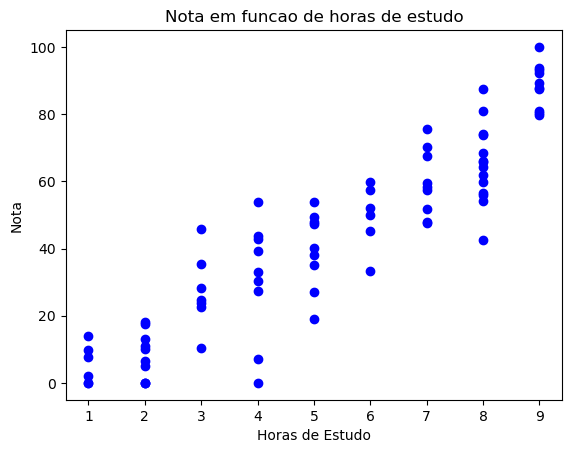

Correlacao: 0.9180856640311844
Correlacao positiva muito forte: [0.8, 1]


In [7]:
# Correlacao de notas e horas_estudo


def getCorrInterpretation(correlacao):
    if (correlacao < -0.8):
        print ("Correlacao negativa forte: [-1.0, -0.8)")
    elif (correlacao < -0.6):
        print ("Correlacao negativa forte: [-0.8, -0.6)")
    elif (correlacao < -0.4):
        print ("Correlacao negativa media: [-0.6, -0.4)")
    elif (correlacao < -0.2):
        print ("Correlacao negativa fraca: [-0.4, -0.2)")
    elif (correlacao < 0.2):
        print ("Correlacao negligivel: [-0.2, 0.2)")
    elif (correlacao < 0.4):
        print ("Correlacao positiva fraca: [-0.2, 0.4)")
    elif (correlacao < 0.6):
        print ("Correlacao positiva media: [-0.4, 0.6)")
    elif (correlacao < 0.8):
        print ("Correlacao positiva forte: [0.6, 0.8)")
    else:
        print ("Correlacao positiva muito forte: [0.8, 1]")



def getCorr(df, titulo, coluna1, xLabel, coluna2, yLabel):
    plt.scatter(df[coluna1], df[coluna2], color='blue', marker='o')
    
    plt.title(titulo)
    plt.xlabel(xLabel)
    plt.ylabel(yLabel)
    
    plt.show()
    
    correlacao = df[coluna1].corr(df[coluna2])
    print (f"Correlacao: {correlacao}")
    getCorrInterpretation(correlacao)




getCorr(df, "Nota em funcao de horas de estudo", 'horas_estudo', "Horas de Estudo", 'nota', "Nota")


# Analise: Ha uma forte correlacao entre horas de estudo e nota
#          Logo, seria benefico incentivar alunos a estudar mais horas

## Exercício 7
Descreva e analise algo relevante nos dados.

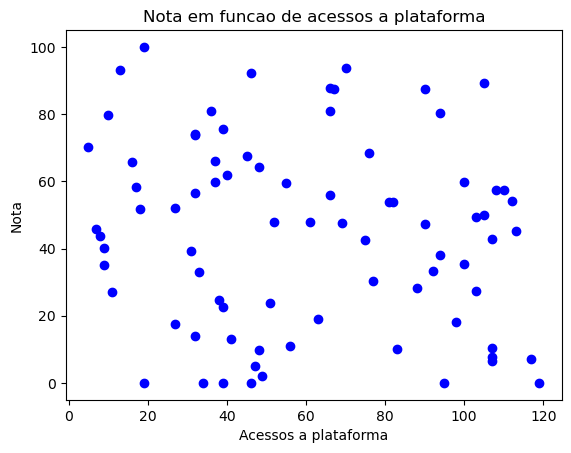

Correlacao: -0.14007793949003985
Correlacao negligivel: [-0.2, 0.2)


In [8]:
# Correlacao de notas e acessos_plataforma


getCorr(df, "Nota em funcao de acessos a plataforma", 'acessos_plataforma', "Acessos a plataforma", 'nota', "Nota")



# Analise: Nao ha correlacao significativa entre acessos a plataforma e notas

## Exercício 8
Descreva e analise algo relevante nos dados.

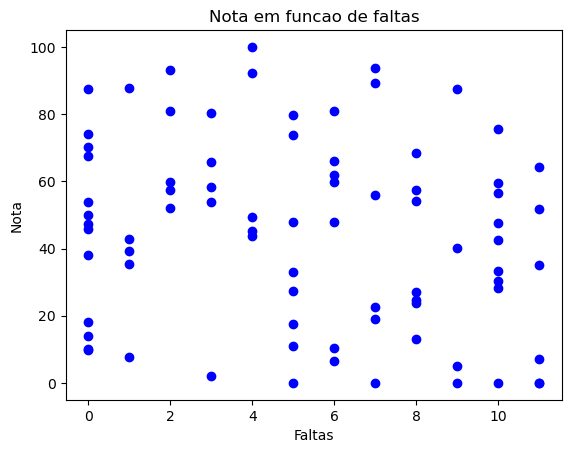

Correlacao: -0.19672431514472125
Correlacao negligivel: [-0.2, 0.2)


In [9]:
# Correlacao de notas e faltas


getCorr(df, "Nota em funcao de faltas", 'faltas', "Faltas", 'nota', "Nota")


# Analise: Nao ha correlacao significativa entre notas e faltas, mas beira de ser negativa fraca

## Exercício 9
Descreva e analise algo relevante nos dados.

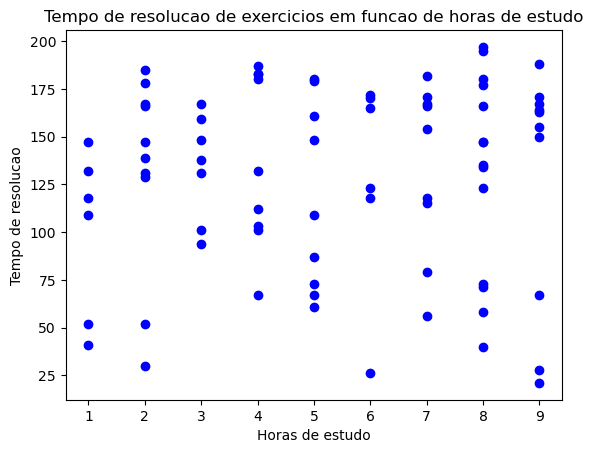

Correlacao: 0.05997718156905911
Correlacao negligivel: [-0.2, 0.2)


In [10]:
# Correlacao de tempo_resolucao e horas_estudo


getCorr(df, "Tempo de resolucao de exercicios em funcao de horas de estudo", 'horas_estudo', "Horas de estudo", 'tempo_resolucao', "Tempo de resolucao")


# Analise: Nao ha correlacao significativa entre tempo de resolucao e horas de estudo

## Exercício 10
Descreva e analise algo relevante nos dados.

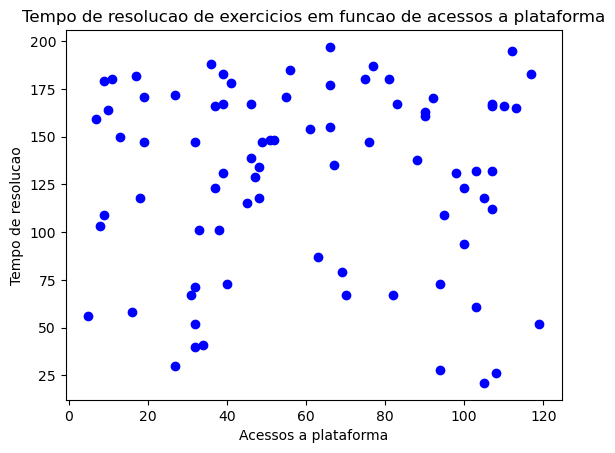

Correlacao: -0.019659436267415988
Correlacao negligivel: [-0.2, 0.2)


In [11]:
# Correlacao de tempo_resolucao e acessos_plataforma


getCorr(df, "Tempo de resolucao de exercicios em funcao de acessos a plataforma", 'acessos_plataforma', "Acessos a plataforma", 'tempo_resolucao', "Tempo de resolucao")


# Analise: Nao ha correlacao significativa entre tempo de resolucao e acessos a plataforma

## Exercício 11
Descreva e analise algo relevante nos dados.

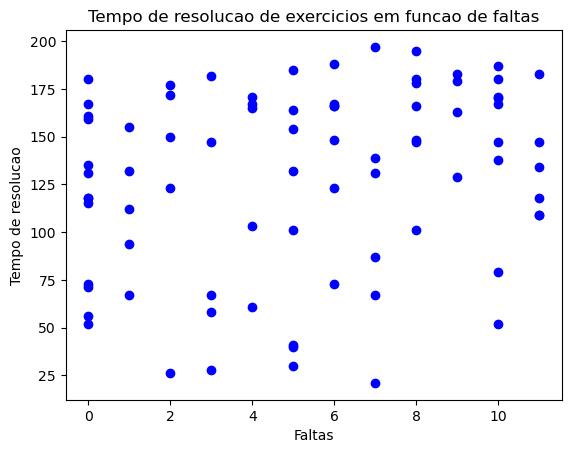

Correlacao: 0.2287070605017316
Correlacao positiva fraca: [-0.2, 0.4)


In [12]:
# Correlacao de tempo_resolucao e faltas


getCorr(df, "Tempo de resolucao de exercicios em funcao de faltas", 'faltas', "Faltas", 'tempo_resolucao', "Tempo de resolucao")


# Analise: Há correlação fraca entre tempo de resolução de exericicos e faltas
#          Logo, incentivar alunos a não faltarem pode ajudar levemente na facilidade de resolver exercicios

## Exercício 12
Descreva e analise algo relevante nos dados.

In [27]:
# Media, mediana e desvio padrao de horas_estudo


def getInfoFromDF(df, coluna):
    print (f"Informacoes sobre {coluna}")
    print (f"\tMedia: \t\t{np.mean(df[coluna])}")
    print (f"\tMediana: \t{np.median(df[coluna])}")
    print (f"\tDesvio Padrao: \t{np.std(df[coluna])}\n")


getInfoFromDF(df, 'horas_estudo')


# Analise: Ha grande varianca entre horas de estudo, e como ha correlacao muito forte entre notas e horas de estudo
#          Seria util incentivar alunos que estudam menos a estudar mais

Informacoes sobre horas_estudo
	Media: 		5.3625
	Mediana: 	5.0
	Desvio Padrao: 	2.5992486895254943



## Exercício 13
Descreva e analise algo relevante nos dados.

In [30]:
# horas_estudo por turno


def getInfo(alvo, estudo, data):
    print (f"Informacoes sobre {estudo}")
    print (f"\tMedia: \t\t{np.mean(data)}")
    print (f"\tMediana: \t{np.median(data)}")
    print (f"\tDesvio Padrao: \t{np.std(data)}\n")


for turno in turnos:
    horas = getDataWhere(df, 'horas_estudo', 'turno', turno)
    print (f"Turno: {turno}")
    getInfo(turno, "Horas de estudo", horas)


# Analise: Ambos turnos sao similares

Turno: Manhã
Informacoes sobre Horas de estudo
	Media: 		5.428571428571429
	Mediana: 	5.0
	Desvio Padrao: 	2.5555062599997598

Turno: Noite
Informacoes sobre Horas de estudo
	Media: 		5.311111111111111
	Mediana: 	5.0
	Desvio Padrao: 	2.6316215721044376



## Exercício 14
Descreva e analise algo relevante nos dados.

In [25]:
# horas_estudo por linguagem


for lingua in linguagens:
    horas = getDataWhere(df, 'horas_estudo', 'linguagem', lingua)
    print (f"Lingua: {lingua}")
    getInfo(lingua, horas)


# Analise: Pequena diferenca, mas pouco significativa entre linguagens
#          Combinado com as 2 analises anteriores, o incentivo a mais estudo engloba todas as salas

Lingua: Java
Informacoes sobre Java
	Media: 		5.096774193548387
	Mediana: 	5.0
	Desvio Padrao: 	2.8324711507761533

Lingua: C
Informacoes sobre C
	Media: 		5.35
	Mediana: 	5.5
	Desvio Padrao: 	2.4140215409146624

Lingua: Python
Informacoes sobre Python
	Media: 		5.655172413793103
	Mediana: 	6.0
	Desvio Padrao: 	2.4250966858644474



## Exercício 15
Descreva e analise algo relevante nos dados.

In [28]:
# Media, mediana e desvio padrao de tempo_resolucao


getInfoFromDF(df, 'tempo_resolucao')


# Analise: Ha grande varianca entre tempos de resolucao
#          Seria util descobrir onde ha dificuldades para os alunos

Informacoes sobre tempo_resolucao
	Media: 		128.4125
	Mediana: 	138.5
	Desvio Padrao: 	48.03194087011267



## Exercício 16
Descreva e analise algo relevante nos dados.

In [33]:
# tempo_resolucao por turno


for turno in turnos:
    tempo = getDataWhere(df, 'tempo_resolucao', 'turno', turno)
    print (f"Turno: {turno}")
    getInfo(turno, "Tempo de resolucao", tempo)


# Analise: Pequena diferenca, mas pouco significativa entre turnos

Turno: Manhã
Informacoes sobre Tempo de resolucao
	Media: 		134.77142857142857
	Mediana: 	150.0
	Desvio Padrao: 	44.05197301518528

Turno: Noite
Informacoes sobre Tempo de resolucao
	Media: 		123.46666666666667
	Mediana: 	132.0
	Desvio Padrao: 	50.36074308868411



## Exercício 17
Descreva e analise algo relevante nos dados.

In [34]:
# tempo_resolucao por linguagem


for lingua in linguagens:
    tempo = getDataWhere(df, 'tempo_resolucao', 'linguagem', lingua)
    print (f"Lingua: {lingua}")
    getInfo(lingua, "Tempo de resolucao", tempo)


# Analise: Pequena diferenca, mas pouco significativa entre linguagens
#          Combinado com as 2 analises anteriores, ha dificuldades desiguais em todas as salas

Lingua: Java
Informacoes sobre Tempo de resolucao
	Media: 		129.6451612903226
	Mediana: 	138.0
	Desvio Padrao: 	48.1379391568055

Lingua: C
Informacoes sobre Tempo de resolucao
	Media: 		120.55
	Mediana: 	140.5
	Desvio Padrao: 	47.550473183765476

Lingua: Python
Informacoes sobre Tempo de resolucao
	Media: 		132.51724137931035
	Mediana: 	139.0
	Desvio Padrao: 	47.61093810116296



## Exercício 18
Descreva e analise algo relevante nos dados.

In [35]:
# Media, mediana e desvio padrao de faltas


getInfoFromDF(df, 'faltas')


# Analise: Ha grande varianca entre faltas
#          Seria util desincentivar faltas entre os que mais faltam

Informacoes sobre faltas
	Media: 		5.275
	Mediana: 	5.0
	Desvio Padrao: 	3.653679652076794



## Exercício 19
Descreva e analise algo relevante nos dados.

In [36]:
# faltas por turno


for turno in turnos:
    tempo = getDataWhere(df, 'faltas', 'turno', turno)
    print (f"Turno: {turno}")
    getInfo(turno, "Faltas", tempo)


# Analise: Pequena diferenca, mas pouco significativa entre turnos

Turno: Manhã
Informacoes sobre Faltas
	Media: 		4.6
	Mediana: 	5.0
	Desvio Padrao: 	3.5952349416573997

Turno: Noite
Informacoes sobre Faltas
	Media: 		5.8
	Mediana: 	6.0
	Desvio Padrao: 	3.6123245824384176



## Exercício 20
Descreva e analise algo relevante nos dados.

In [37]:
# faltas por linguagem


for lingua in linguagens:
    tempo = getDataWhere(df, 'faltas', 'linguagem', lingua)
    print (f"Lingua: {lingua}")
    getInfo(lingua, "Faltas", tempo)


# Analise: Alunos de C faltam significativamente menos que outras linguagens
#          Combinado com as analises sobre faltas e sobre tempo de resolucao
#          Reduzir faltas em Java e Python podem ajudar um pouco a reduzir
#          Dificuldades em resolucao de exercicios

Lingua: Java
Informacoes sobre Faltas
	Media: 		6.225806451612903
	Mediana: 	7.0
	Desvio Padrao: 	3.7131820752326896

Lingua: C
Informacoes sobre Faltas
	Media: 		3.75
	Mediana: 	3.0
	Desvio Padrao: 	3.433292880020579

Lingua: Python
Informacoes sobre Faltas
	Media: 		5.310344827586207
	Mediana: 	5.0
	Desvio Padrao: 	3.3743806407517427

